<a href="https://colab.research.google.com/github/Umraz1413/AI-Smart-assistant/blob/main/CNN_FTT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup Google Colab Environment
Install required libraries

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow opencv-python

# Download Dataset

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir  ~/.kaggle

In [ ]:
!cp "/content/drive/MyDrive/kaggle API/kaggle.json" ~/.kaggle/

In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download ashrafulhossenakash/alzheimer-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/ashrafulhossenakash/alzheimer-disease-dataset
License(s): CC0-1.0
100% 373M/373M [00:21<00:00, 18.0MB/s]



In [ ]:
!unzip -o /content/alzheimer-disease-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (14).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (15).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (16).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (17).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (18).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (19).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (2).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (20).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (21).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (22).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (23).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (24).jpg  
  inflating: Alzheimer_Dataset_V3/Unaugmented/MildDemented/30 (25).jpg  
 

In [ ]:
import os

base_path = "/content/Alzheimer_Dataset_V3"

if os.path.isdir(base_path):
    print(os.listdir(base_path))
else:
    print(f"Error: Directory '{base_path}' does not exist.")
    print("Please ensure the dataset has been unzipped correctly in a previous step.")

['Augmented', 'Unaugmented']


In [ ]:
!ls -F /content/Alzheimer_Dataset_V3/Unaugmented/

MildDemented/  ModerateDemented/  NonDemented/	VeryMildDemented/


# Data Preprocessing

In [ ]:
import os
import cv2
import numpy as np

data_dir = "/content/Alzheimer_Dataset_V3/Unaugmented" # Corrected path to Unaugmented

categories = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]

images = []
labels = []

for category in categories:
    path = os.path.join(data_dir, category)
    label = categories.index(category)

    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        image = cv2.imread(img_path)
        image = cv2.resize(image, (32, 32)) # Further reduced image size to 32x32

        images.append(image)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

# Apply FFT
Apply FFT

### What is Fast Fourier Transform (FFT)?

The Fast Fourier Transform (FFT) is an algorithm that computes the Discrete Fourier Transform (DFT) of a sequence, or its inverse (IDFT). In simple terms, it breaks down a signal (like an image) into its constituent frequencies. Think of it like separating a musical chord into its individual notes.

#### Why use FFT in image processing?

When applied to images, the FFT transforms the image from its spatial domain (pixels and their intensity values) to the frequency domain (components representing how quickly pixel values change across the image).

*   **Low Frequencies:** Represent the general structure, overall brightness, and slow variations in intensity (e.g., large objects, background).
*   **High Frequencies:** Represent fine details, edges, textures, and rapid changes in intensity (e.g., sharp lines, noise).

By including FFT features alongside the raw pixel data, the model can potentially learn from both spatial and frequency characteristics of the images. This can be beneficial for tasks like image classification, as it provides a richer representation of the data, sometimes highlighting patterns that are not immediately obvious in the spatial domain alone.

In [ ]:
import numpy as np
import cv2

def apply_fft(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20*np.log(np.abs(fshift) + 1)
    return magnitude_spectrum.astype(np.float32) # Cast to float32 to save memory

fft_images = np.array([apply_fft(img) for img in images])
fft_images = fft_images.reshape(-1, 32, 32, 1) # Reshaped to 32x32 to match new image size

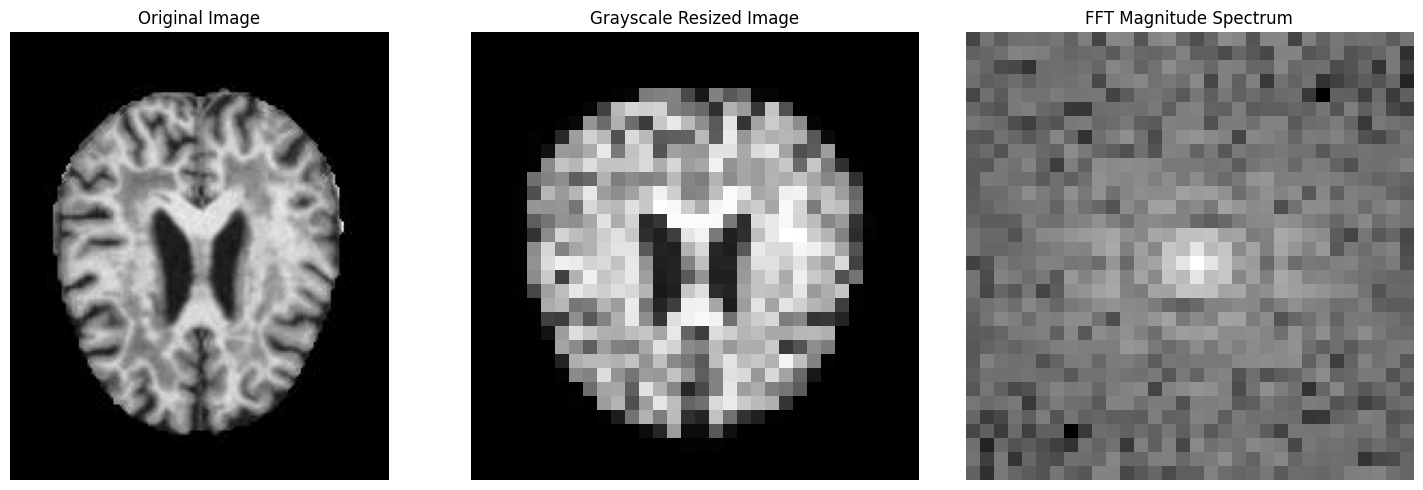

In [ ]:
import os # Ensure os is imported first
import matplotlib.pyplot as plt
import cv2

# Ensure data_dir is defined. If not, fallback to a sensible default or alert the user.
if 'data_dir' not in globals():
    # This might happen if previous cells were not run. Provide a reasonable default.
    print("Warning: `data_dir` is not defined. Using a default path. Please ensure previous cells are run.")
    data_dir = "/content/Alzheimer_Dataset_V3/Unaugmented" # Fallback to the known correct path

# Let's pick an example image to visualize its FFT
# We'll use the first image from the 'images' array after resizing and normalization
# Or, if an example_image_path exists, we'll use that.

# Ensure example_image_path is defined; if not, define one for demonstration
if 'example_image_path' not in locals() or example_image_path is None:
    # Fallback if example_image_path wasn't generated or found previously
    non_demented_path = os.path.join(data_dir, "NonDemented")
    files_in_nondemented = os.listdir(non_demented_path)
    image_files = [f for f in files_in_nondemented if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if image_files:
        example_image_path = os.path.join(non_demented_path, image_files[0])
    else:
        print("Could not find an example image to display FFT. Please ensure the dataset is downloaded and extracted.")
        example_image_path = None # Set to None if no image is found

if example_image_path:
    img_original = cv2.imread(example_image_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib display

    # Resize for consistency with model input, but keep original for display
    img_resized = cv2.resize(img_original, (32, 32))

    # Convert to grayscale
    gray_img = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

    # Apply FFT
    f = np.fft.fft2(gray_img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)

    # Plotting
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_original)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(gray_img, cmap='gray')
    plt.title('Grayscale Resized Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title('FFT Magnitude Spectrum')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot display FFT images as no example image path was found.")

In [ ]:
images = images / 255.0
fft_images = fft_images / np.max(fft_images)

combined = np.concatenate((images, fft_images), axis=-1)

# **Train-Test Split**

### Dataset Distribution into Test and Train

In machine learning, it's crucial to split your dataset into at least two parts:

1.  **Training Set**: Used to train the model, allowing it to learn patterns and relationships within the data.
2.  **Testing Set**: Used to evaluate the model's performance on data it has never seen before. This gives an unbiased estimate of the model's generalization capability.

The code in cell `ElMZF08cR0ic` uses `sklearn.model_selection.train_test_split` to achieve this:

```python
X_train, X_test, y_train, y_test = train_test_split(
    combined, labels, test_size=0.2, random_state=42
)
```

Let's break down the parameters:

*   `combined`: This is your feature set, which includes both the original resized image data and the FFT magnitude spectrum, concatenated along the channel axis. This combined data serves as the input to your CNN model.
*   `labels`: These are the corresponding labels (e.g., 0 for Mild Demented, 1 for Moderate Demented, etc.) for each image in the `combined` dataset.
*   `test_size=0.2`: This parameter specifies the proportion of the dataset to be allocated to the test set. In this case, 20% of the total data will be used for testing, and the remaining 80% will be used for training.
*   `random_state=42`: This parameter is used for reproducibility. When you set `random_state` to a specific integer (like 42), the split will always be the same every time you run the code. If `random_state` is not set, the split will be different each time, which can make it difficult to compare experiments.

After this split, you get four new variables:

*   `X_train`: The features for the training set (80% of `combined`).
*   `X_test`: The features for the test set (20% of `combined`).
*   `y_train`: The labels corresponding to `X_train` (80% of `labels`).
*   `y_test`: The labels corresponding to `X_test` (20% of `labels`).

This ensures that your model is trained on a portion of the data and then evaluated on a completely separate, unseen portion, providing a more reliable measure of its real-world performance.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    combined, labels, test_size=0.2, random_state=42
)

# **Build CNN Model**

### What is a Convolutional Neural Network (CNN)?

AConvolutional Neural Network (CNN or ConvNet) is a specialized type of neural network primarily used for analyzing visual imagery. They are incredibly effective in tasks like image classification, object detection, and image segmentation.

#### Key Components of a CNN:

1.  **Convolutional Layer:** This is the core building block of a CNN. It applies a set of learnable filters (kernels) to the input image, performing a convolution operation. Each filter detects specific features (e.g., edges, textures, corners) in different regions of the image, producing a feature map.

2.  **Activation Function (e.g., ReLU):** After the convolution operation, an activation function (commonly Rectified Linear Unit, or ReLU) is applied to introduce non-linearity into the model, allowing it to learn more complex patterns.

3.  **Pooling Layer (e.g., MaxPooling):** Pooling layers reduce the spatial dimensions (width and height) of the feature maps, thereby reducing the number of parameters and computational cost. MaxPooling is a common type, which takes the maximum value from a cluster of neurons in the previous layer.

4.  **Fully Connected Layer:** After several convolutional and pooling layers, the high-level features learned by the network are flattened into a single vector and fed into one or more fully connected layers. These layers are similar to those in traditional neural networks, where each neuron is connected to all neurons in the previous layer.

5.  **Output Layer:** The final fully connected layer typically uses an activation function like softmax (for multi-class classification) or sigmoid (for binary classification) to output the probabilities for each class.

#### Why are CNNs effective for Image Processing?

*   **Parameter Sharing:** Filters are shared across different regions of the image, significantly reducing the number of parameters the model needs to learn.
*   **Sparsity of Connections:** Each neuron in a convolutional layer only connects to a local region of the input, making the network more efficient.
*   **Equivariance to Translation:** CNNs can detect features regardless of their position in the image, meaning if a pattern shifts slightly in the input, the CNN will still recognize it.
*   **Hierarchical Feature Learning:** Earlier layers learn low-level features (edges, corners), and deeper layers combine these to learn more complex, high-level features (parts of objects, entire objects).

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,4))) # Corrected input_shape
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))  # 4 classes

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Model

In [ ]:
from tensorflow.keras.utils import to_categorical

# Convert labels to one-hot encoding
y_train_one_hot = to_categorical(y_train, num_classes=4);
y_test_one_hot = to_categorical(y_test, num_classes=4);

# Re-compile the model to ensure a fresh state for tf.function tracing
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train_one_hot, epochs=10, validation_data=(X_test, y_test_one_hot))

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.2829 - loss: 1.3791 - val_accuracy: 0.2657 - val_loss: 1.3800
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2824 - loss: 1.3786 - val_accuracy: 0.2657 - val_loss: 1.3781
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2832 - loss: 1.3759 - val_accuracy: 0.2657 - val_loss: 1.3781
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2890 - loss: 1.3768 - val_accuracy: 0.2657 - val_loss: 1.3755
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3013 - loss: 1.3602 - val_accuracy: 0.3667 - val_loss: 1.3081
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4499 - loss: 1.1857 - val_accuracy: 0.4853 - val_loss: 1.0946
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4881 - loss: 1.0419 - val_accuracy: 0.5245 - val_loss: 0.9729
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5156 - loss: 0.9819 - val_accuracy: 

# Evaluate Performance

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test_one_hot)
print("Accuracy:", accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5833 - loss: 0.8344
Accuracy: 0.5833333134651184


# performance metrics

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test # Corrected: y_test is already a 1D array of integer labels

print(classification_report(y_true, y_pred_classes))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.60      0.67      0.63       281
           1       0.97      0.70      0.82       195
           2       0.51      0.84      0.64       271
           3       0.36      0.16      0.22       273

    accuracy                           0.58      1020
   macro avg       0.61      0.59      0.57      1020
weighted avg       0.58      0.58      0.56      1020



### Detailed Performance Metrics

Let's view the precision, recall (sensitivity), and F1-score for each class in a structured table.

### Prepare data for a normal CNN (without FFT)

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical # Added import

# Split the original images data into training and testing sets
X_train_normal, X_test_normal, y_train_normal, y_test_normal = train_test_split(
    images, labels, test_size=0.2, random_state=42
)

# Convert labels to one-hot encoding for the new model
y_train_normal_one_hot = to_categorical(y_train_normal, num_classes=4);
y_test_normal_one_hot = to_categorical(y_test_normal, num_classes=4);

### Build and Train a Normal CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model_normal_cnn = Sequential()

# Input shape is (32, 32, 3) for RGB images
model_normal_cnn.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model_normal_cnn.add(MaxPooling2D(2,2))

model_normal_cnn.add(Conv2D(64, (3,3), activation='relu'))
model_normal_cnn.add(MaxPooling2D(2,2))

model_normal_cnn.add(Conv2D(128, (3,3), activation='relu'))
model_normal_cnn.add(MaxPooling2D(2,2))

model_normal_cnn.add(Flatten())
model_normal_cnn.add(Dense(128, activation='relu'))
model_normal_cnn.add(Dropout(0.5))

model_normal_cnn.add(Dense(4, activation='softmax'))  # 4 classes

model_normal_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training the Normal CNN Model...")
history_normal_cnn = model_normal_cnn.fit(X_train_normal, y_train_normal_one_hot, epochs=10, validation_data=(X_test_normal, y_test_normal_one_hot))

Training the Normal CNN Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.4177 - loss: 1.2404 - val_accuracy: 0.6206 - val_loss: 1.0295
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6359 - loss: 0.8168 - val_accuracy: 0.7039 - val_loss: 0.6603
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7046 - loss: 0.6329 - val_accuracy: 0.6951 - val_loss: 0.6177
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7345 - loss: 0.5670 - val_accuracy: 0.7667 - val_loss: 0.5344
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7798 - loss: 0.4897 - val_accuracy: 0.7755 - val_loss: 0.4927
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8078 - loss: 0.4504 - val_accuracy: 0.8245 - val_loss: 0.4203
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8470 - loss: 0.3771 - val_accuracy: 0.8275 - val_loss: 0.3900
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8789 - loss: 0.3025 - val_accuracy: 0

### Evaluate Performance of Normal CNN

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

loss_normal_cnn, accuracy_normal_cnn = model_normal_cnn.evaluate(X_test_normal, y_test_normal_one_hot)
print("Normal CNN Accuracy:", accuracy_normal_cnn)

# Get predictions and generate classification report
y_pred_normal_cnn = model_normal_cnn.predict(X_test_normal)
y_pred_classes_normal_cnn = np.argmax(y_pred_normal_cnn, axis=1)

print("\nClassification Report for Normal CNN:")
print(classification_report(y_test_normal, y_pred_classes_normal_cnn, target_names=categories))

# Display as DataFrame for better comparison
report_dict_normal_cnn = classification_report(y_test_normal, y_pred_classes_normal_cnn, target_names=categories, output_dict=True)
metrics_df_normal_cnn = pd.DataFrame(report_dict_normal_cnn).transpose()
print("\nClassification Report for Normal CNN as DataFrame:")
display(metrics_df_normal_cnn.loc[categories])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9000 - loss: 0.2635
Normal CNN Accuracy: 0.8999999761581421
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Classification Report for Normal CNN:
                  precision    recall  f1-score   support

    MildDemented       0.96      0.94      0.95       281
ModerateDemented       1.00      1.00      1.00       195
     NonDemented       0.83      0.90      0.86       271
VeryMildDemented       0.84      0.79      0.82       273

        accuracy                           0.90      1020
       macro avg       0.91      0.91      0.91      1020
    weighted avg       0.90      0.90      0.90      1020


Classification Report for Normal CNN as DataFrame:


,precision,recall,f1-score,support
MildDemented,0.956522,0.939502,0.947935,281.0
ModerateDemented,1.000000,1.000000,1.000000,195.0
NonDemented,0.829352,0.896679,0.861702,271.0
VeryMildDemented,0.843750,0.791209,0.816635,273.0


### Confusion Matrix for Model with FFT and RGB Combined

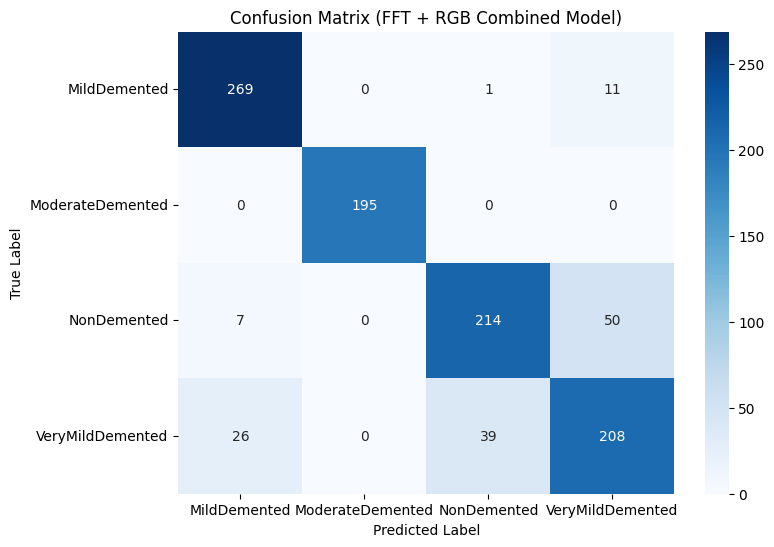

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix for the FFT + RGB combined model
cm_combined = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix (FFT + RGB Combined Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Confusion Matrix for Normal CNN Model (RGB Only)

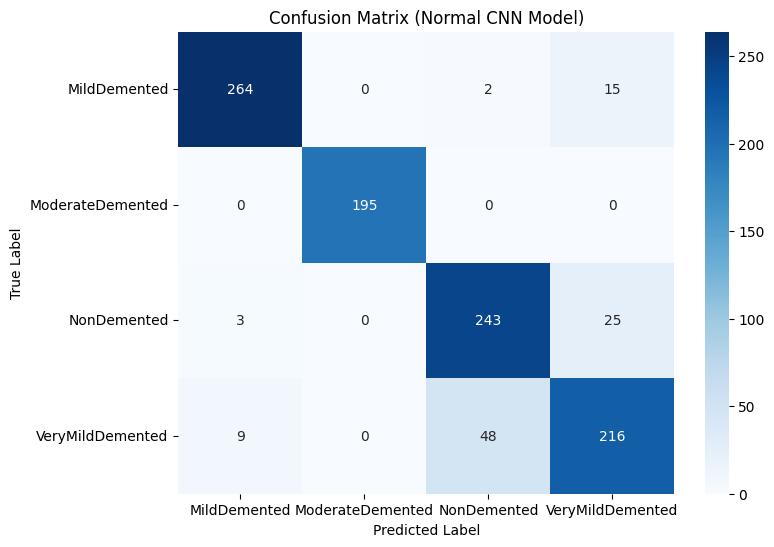

In [ ]:
# Generate confusion matrix for the Normal CNN model
cm_normal = confusion_matrix(y_test_normal, y_pred_classes_normal_cnn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normal, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix (Normal CNN Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Comparison of Models

Below is a summary of the performance for both models:

**Current Model (with FFT and RGB combined):**


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Get the classification report as a dictionary for the combined model
report_dict = classification_report(y_true, y_pred_classes, target_names=categories, output_dict=True)

# Convert the dictionary to a pandas DataFrame for better visualization
metrics_df = pd.DataFrame(report_dict).transpose()

display(metrics_df.loc[categories])

,precision,recall,f1-score,support
MildDemented,0.890728,0.957295,0.922813,281.0
ModerateDemented,1.000000,1.000000,1.000000,195.0
NonDemented,0.842520,0.789668,0.815238,271.0
VeryMildDemented,0.773234,0.761905,0.767528,273.0


**Normal CNN Model (with only RGB images):**

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# Get the classification report as a dictionary
report_dict = classification_report(y_true, y_pred_classes, target_names=categories, output_dict=True)

# Convert the dictionary to a pandas DataFrame for better visualization
metrics_df = pd.DataFrame(report_dict).transpose()

# Display the DataFrame, focusing on class-specific metrics
print("Classification Report as DataFrame:")
display(metrics_df.loc[categories])

Classification Report as DataFrame:


,precision,recall,f1-score,support
MildDemented,0.890728,0.957295,0.922813,281.0
ModerateDemented,1.000000,1.000000,1.000000,195.0
NonDemented,0.842520,0.789668,0.815238,271.0
VeryMildDemented,0.773234,0.761905,0.767528,273.0


# Reduce False Positives & Negatives

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rotation_range=20, zoom_range=0.2, horizontal_flip=True)

# Visualize Results

### Visualize Data Augmentation (Rotation and Flipping)

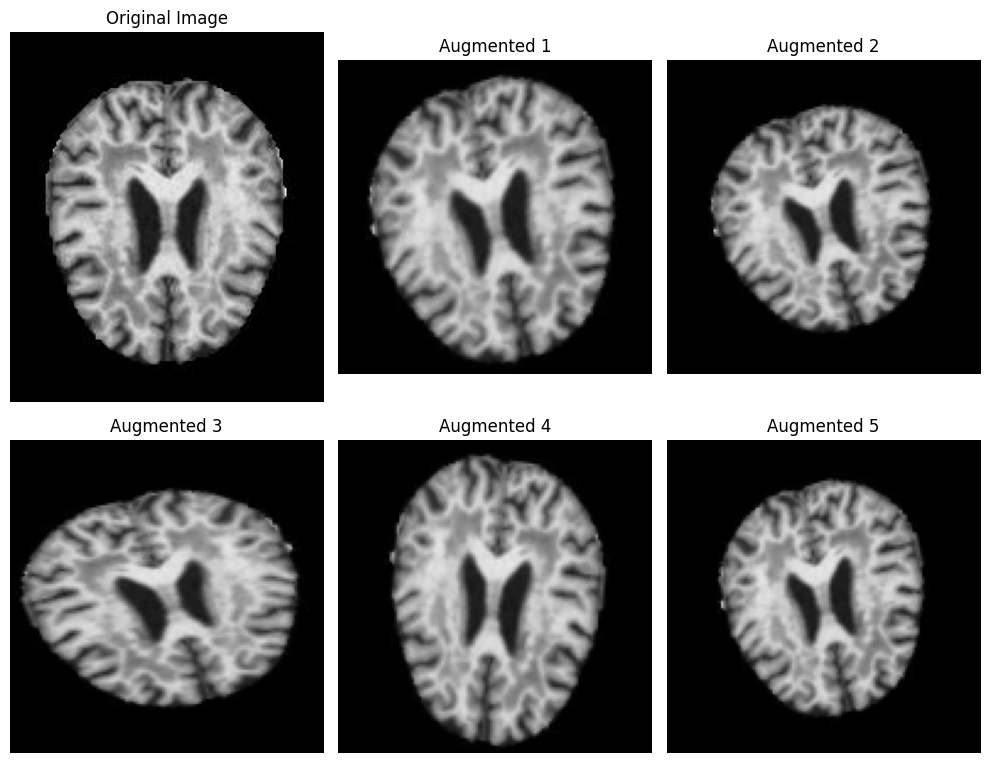

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

# Ensure datagen is defined (if not already, which it should be from previous steps)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
if 'datagen' not in globals():
    datagen = ImageDataGenerator(rotation_range=20, zoom_range=0.2, horizontal_flip=True)

# Get an example image path, similar to the prediction function
example_image_path = None
non_demented_path = os.path.join('/content/Alzheimer_Dataset_V3/Unaugmented', 'NonDemented')
files_in_nondemented = os.listdir(non_demented_path)

if files_in_nondemented:
    image_files = [f for f in files_in_nondemented if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if image_files:
        example_image_path = os.path.join(non_demented_path, image_files[0])

if example_image_path:
    # Load the original image for clear display
    img_original = cv2.imread(example_image_path)
    if img_original is None:
        print(f"Error: Could not load image at {example_image_path}")
    else:
        img_display = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB) # Convert to RGB for matplotlib display

        # Resize for display augmentation (e.g., 128x128 or its original size if smaller)
        # This size is only for visualization, not for model input.
        display_size_for_aug = 128 # You can adjust this value for desired display quality
        img_for_display_augmentation = cv2.resize(img_display, (display_size_for_aug, display_size_for_aug))
        img_for_display_augmentation = img_for_display_augmentation.astype('float32') / 255.0 # Normalize

        # Expand dimensions to create a batch of 1 image for the generator (for display augmentation)
        img_batch_for_display = np.expand_dims(img_for_display_augmentation, 0)

        plt.figure(figsize=(10, 8))
        plt.subplot(2, 3, 1)
        plt.imshow(img_display) # Display the clearer, original image (full resolution if possible)
        plt.title('Original Image')
        plt.axis('off')

        i = 2
        for batch in datagen.flow(img_batch_for_display, batch_size=1):
            if i > 6:
                break
            plt.subplot(2, 3, i)
            plt.imshow(batch[0])
            plt.title(f'Augmented {i-1}')
            plt.axis('off')
            i += 1
        plt.tight_layout()
        plt.show()
else:
    print("Could not find an example image to demonstrate augmentation.")

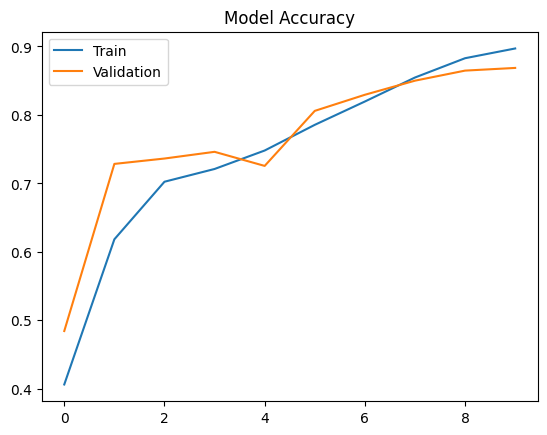

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

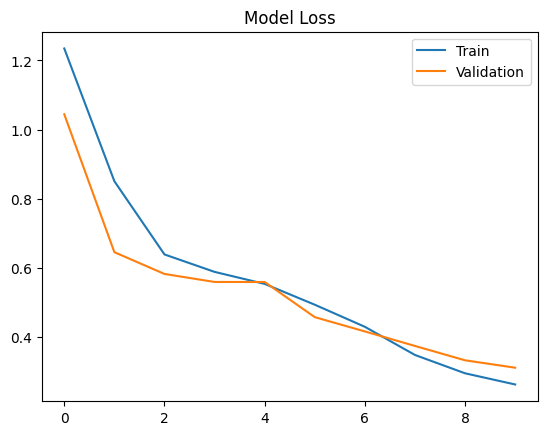

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(['Train', 'Validation'])
plt.show()

# Detect Alzheimer's stages

In [ ]:
class_names = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very Mild Demented']

# Predict A Single Image

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE = 32 # Model input size

def predict_image(image_path):
    # Load image in its original resolution
    img_original = cv2.imread(image_path)
    if img_original is None:
        print(f"Error: Could not load image at {image_path}")
        return None

    # Resize for model input (this will be used for prediction)
    img_resized_for_model = cv2.resize(img_original, (IMG_SIZE, IMG_SIZE))
    img_normalized = img_resized_for_model / 255.0

    # Apply FFT to grayscale version of the normalized image
    gray = cv2.cvtColor(img_normalized.astype('float32'), cv2.COLOR_BGR2GRAY)
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = 20*np.log(np.abs(fshift) + 1)

    # Normalize FFT magnitude
    magnitude = magnitude / np.max(magnitude)

    # Reshape magnitude to (IMG_SIZE, IMG_SIZE, 1)
    magnitude_reshaped = magnitude.reshape(IMG_SIZE, IMG_SIZE, 1)

    # Combine RGB image and FFT magnitude to create 4-channel input
    combined_input = np.concatenate((img_normalized, magnitude_reshaped), axis=-1);

    # Add batch dimension for prediction
    final_input = np.expand_dims(combined_input, axis=0)

    # Prediction step ✅
    prediction = model.predict(final_input)
    predicted_class = np.argmax(prediction)

    # Display the original image (or a larger, clearer version)
    plt.figure(figsize=(6, 6))
    # For display, resize the original image to a larger size if needed, or just display original
    display_img = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    plt.imshow(display_img)
    plt.title(f"Predicted: {class_names[predicted_class]}")
    plt.axis('off')
    plt.show()

    return class_names[predicted_class]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step


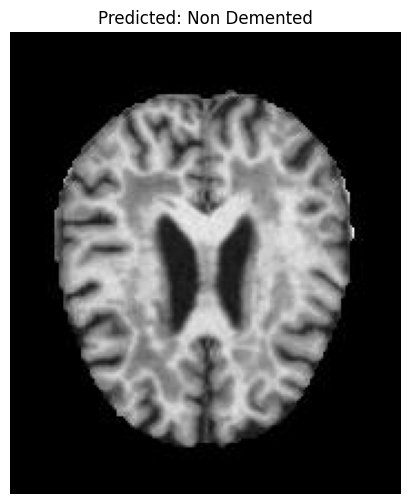

In [ ]:
import os

# Find an existing image path dynamically
example_image_path = None
non_demented_path = os.path.join(data_dir, "NonDemented")
files_in_nondemented = os.listdir(non_demented_path)

if files_in_nondemented:
    # Filter for image files (e.g., .jpg, .png)
    image_files = [f for f in files_in_nondemented if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if image_files:
        example_image_path = os.path.join(non_demented_path, image_files[0])

if example_image_path:
    predict_image(example_image_path)
else:
    print(f"No image files found in {non_demented_path} to predict.")

In [ ]:
from google.colab import files

print("Please upload your image file:")
uploaded = files.upload()

# Get the filename of the uploaded image
for fn in uploaded.keys():
    uploaded_image_path = f"/content/{fn}"
    print(f"User uploaded file '{fn}'")

Please upload your image file:


In [ ]:
# Predict with the uploaded image
if 'uploaded_image_path' in locals():
    predicted_class_uploaded = predict_image(uploaded_image_path)
    print(f"The uploaded image was predicted as: {predicted_class_uploaded}")
else:
    print("No image was uploaded.")

# Display Images From Each CLass

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = 128
dataset_path = '/content/Alzheimer_Dataset_V3/Unaugmented' # Corrected path
class_names = ['Mild Demented', 'Moderate Demented', 'Non Demented', 'Very Mild Demented'] # Moved definition here

plt.figure(figsize=(12,8))

for i, class_name in enumerate(class_names):
    folder_path = os.path.join(dataset_path, class_name.replace(" ", ""))

    # get first image from each class
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    plt.subplot(2, 2, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

## Uploading this Colab Notebook to GitHub

To upload this project to GitHub, follow these steps:

1.  **Create a New GitHub Repository:**
    *   Go to [GitHub](https://github.com/) and log in.
    *   Click on the '+' sign in the top right corner and select 'New repository'.
    *   Give your repository a name (e.g., `Alzheimer_Detection_FFT`), an optional description, and choose whether it's public or private. You can choose to initialize it with a README, but it's not strictly necessary for uploading a Colab notebook.
    *   Click 'Create repository'.

2.  **Save a Copy of Your Notebook to GitHub:**
    *   In your Colab notebook, go to `File` > `Save a copy in GitHub...`.
    *   A dialog box will appear. You might need to authenticate Colab with your GitHub account if you haven't already.
    *   Select your newly created repository from the dropdown menu.
    *   You can specify a file path if you want to put it in a subfolder (e.g., `notebooks/alzheimer_detection.ipynb`).
    *   Add a commit message (e.g., "Initial commit of Alzheimer Detection Notebook").
    *   Click 'OK'.

3.  **Verify on GitHub:**
    *   Go back to your GitHub repository page.
    *   You should now see your `.ipynb` file uploaded.

4.  **(Optional) Clone and Work Locally:**
    *   If you want to work on the project locally, clone the repository to your machine:
        ```bash
        git clone https://github.com/YOUR_USERNAME/YOUR_REPOSITORY_NAME.git
        ```
    *   Make your changes, commit them, and push them back to GitHub.

5.  **(Optional) Open in Colab from GitHub:**
    *   You can directly open your GitHub-hosted notebook in Colab by navigating to the `.ipynb` file on GitHub and clicking the 'Open in Colab' badge.